# Phase 4 Model Comparison Summary: QB, RB, WR, TE

This notebook consolidates the results of the four position-specific Keeper Value Score (KVS) models built in Phase 4 (`06a_model_qb.ipynb`, `06b_model_rb.ipynb`, `06c_model_wr.ipynb`, `06d_model_te.ipynb`) into a single side-by-side view. It reproduces no modeling and re-runs no tuning; every number below is loaded directly from each position's saved fold-metrics file or drawn from that position's own notebook.

**Scope.** Four positions are modeled: quarterback (QB), running back (RB), wide receiver (WR), and tight end (TE). Kicker and team defense are excluded from Stage 1 modeling entirely, on grounds documented separately (`06_scope_decision_k_def.ipynb`). Each position model predicts next-season Value Over Replacement Player (VORP) from a locked, position-specific feature set.

## Methodology

Each position model is validated with walk-forward cross-validation: for a given position, seasons are sorted chronologically, the model trains on all seasons up to a cutoff and is scored on the single following season, and the cutoff advances one season at a time. Every position produces 8 such folds, with test seasons 2017 through 2024. No fold's test season ever appears in that fold's training data.

Within each fold, hyperparameters are selected by a 40-trial Optuna search (TPE sampler, median pruning) over `max_depth` (2-8), `min_child_weight` (1-10), `reg_lambda` (log-scale, 0.1-10), `learning_rate` (log-scale, 0.01-0.3), and `subsample` (0.6-1.0), against `XGBRegressor` with early stopping. The search is scored on an inner validation split carved from the most recent season inside that fold's own training window, never on the fold's held-out test season. The final model for each position is trained on all data through 2024, using the median of each hyperparameter across the 8 folds' individually-tuned values.

Each position's feature set was selected in Phase 3 (RFECV under walk-forward cross-validation) and is locked in `config/selected_features.yaml`: QB (6 features), RB (4 features), WR (8 features), TE (9 features). Monotonic constraints are evaluated per position by comparing a fully constrained run against a fully unconstrained run on the same 8 folds; the configuration is adopted only if it does not lose ground on both MAE and Spearman rank correlation simultaneously. The naive baseline used throughout is persistence — predicting that a player's next-season VORP equals their current-season VORP — scored on the identical 8 folds.

Per-fold MAE, RMSE, and Spearman correlation for each position's official model are saved to `data/processed/fold_metrics_<position>.csv`. Naive-baseline statistics, the monotonic-constraint decision, and the diagnostic ratios summarized below are drawn from each position's own notebook, where the underlying computation is shown in full.

## Results

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

POSITIONS = ["QB", "RB", "WR", "TE"]

# Naive-baseline MAE/Spearman, the monotonic-constraint decision, and the diagnostic ratios
# below are drawn directly from each position's own notebook (06a-06d); none of these are
# recomputed here. Per-fold tuned MAE/Spearman are loaded from the saved fold-metrics files.
NAIVE = {
    "QB": {"mae": 72.48, "spearman": 0.666},
    "RB": {"mae": 47.97, "spearman": 0.683},
    "WR": {"mae": 39.34, "spearman": 0.730},
    "TE": {"mae": 27.28, "spearman": 0.691},
}

CONSTRAINT_DECISION = {
    "QB": "Unconstrained",
    "RB": "Constrained",
    "WR": "Unconstrained",
    "TE": "Constrained",
}

CONSTRAINT_BASIS = {
    "QB": "Clean win on both MAE and Spearman",
    "RB": "Clean win on both MAE and Spearman",
    "WR": "Clean win on both MAE and Spearman",
    "TE": "MAE tiebreak; Spearman gap (0.002) within fold-to-fold noise",
}

DELTA_BUCKET_RATIO = {"QB": 1.29, "RB": 1.43, "WR": 1.45, "TE": 1.66}
SCARCITY_TOP_DECILE_RATIO = {"QB": 1.16, "RB": 1.47, "WR": 1.50, "TE": 1.70}
SCARCITY_BOTTOM_DECILE_RATIO = {"QB": 0.55, "RB": 0.57, "WR": 0.59, "TE": 0.57}

rows = []
for pos in POSITIONS:
    fold_df = pd.read_csv(f"../data/processed/fold_metrics_{pos.lower()}.csv")
    tuned_mae = fold_df["mae"].mean()
    tuned_spearman = fold_df["spearman"].mean()
    naive_mae = NAIVE[pos]["mae"]
    naive_spearman = NAIVE[pos]["spearman"]
    rows.append({
        "Position": pos,
        "Naive MAE": round(naive_mae, 2),
        "Tuned MAE": round(tuned_mae, 2),
        "MAE Lift": f"{(naive_mae - tuned_mae) / naive_mae:.1%}",
        "Naive Spearman": round(naive_spearman, 3),
        "Tuned Spearman": round(tuned_spearman, 3),
        "Spearman Delta": round(tuned_spearman - naive_spearman, 3),
        "Constraint Decision": CONSTRAINT_DECISION[pos],
        "Delta-Tail Ratio": DELTA_BUCKET_RATIO[pos],
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

Position  Naive MAE  Tuned MAE MAE Lift  Naive Spearman  Tuned Spearman  Spearman Delta Constraint Decision  Delta-Tail Ratio
      QB      72.48      67.72     6.6%           0.666           0.700           0.034       Unconstrained              1.29
      RB      47.97      46.67     2.7%           0.683           0.691           0.008         Constrained              1.43
      WR      39.34      37.20     5.4%           0.730           0.742           0.012       Unconstrained              1.45
      TE      27.28      26.33     3.5%           0.691           0.689          -0.002         Constrained              1.66


**Table 1.** Naive-baseline and tuned-model performance by position, walk-forward validated across 8 folds (test seasons 2017-2024). Tuned MAE and Spearman are the unweighted mean of each fold's held-out statistic, loaded from `fold_metrics_<position>.csv`. MAE lift is the fractional reduction in mean absolute error from naive to tuned. Delta-Tail Ratio is the `vorp_delta_yoy` extreme-tail degradation ratio (see Cross-Position Findings).

Tuned MAE improves over naive at every position, by 2.7% (RB) to 6.6% (QB). Tuned Spearman improves over naive at QB, RB, and WR; at TE, tuned Spearman (0.689) is marginally below naive (0.691). The monotonic-constraint decision splits 2-2: QB and WR ship unconstrained on a clean two-metric win; RB ships constrained on a clean two-metric win; TE ships constrained on an MAE tiebreak, with the Spearman difference between configurations (0.002) within the range attributable to fold-to-fold noise rather than a genuine second win.

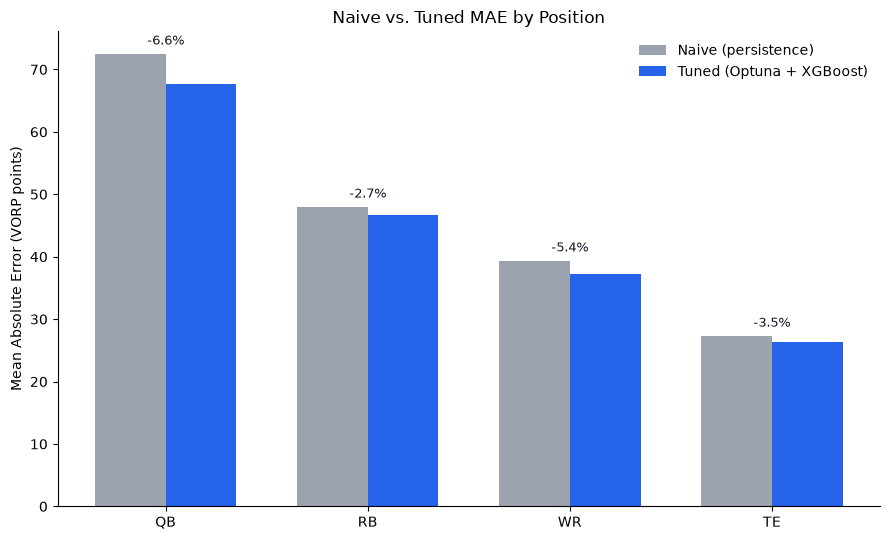

In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(POSITIONS))
width = 0.35

naive_mae_vals = [NAIVE[p]["mae"] for p in POSITIONS]
tuned_mae_vals = [summary_df.loc[summary_df["Position"] == p, "Tuned MAE"].iloc[0] for p in POSITIONS]

bars_naive = ax.bar(x - width / 2, naive_mae_vals, width, label="Naive (persistence)", color="#9CA3AF")
bars_tuned = ax.bar(x + width / 2, tuned_mae_vals, width, label="Tuned (Optuna + XGBoost)", color="#2563EB")

for i, p in enumerate(POSITIONS):
    lift = (naive_mae_vals[i] - tuned_mae_vals[i]) / naive_mae_vals[i]
    ax.annotate(f"-{lift:.1%}", xy=(x[i], max(naive_mae_vals[i], tuned_mae_vals[i]) + 1.5),
                ha="center", fontsize=9, color="#111827")

ax.set_xticks(x)
ax.set_xticklabels(POSITIONS)
ax.set_ylabel("Mean Absolute Error (VORP points)")
ax.set_title("Naive vs. Tuned MAE by Position")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Figure 1.** Naive-baseline MAE (persistence) against tuned-model MAE, by position. Annotated percentages are the fractional MAE reduction. The gap is largest at QB and smallest at RB, consistent with RB's feature set (4 features, dominated by `scarcity_z`) leaving less room for a learned model to improve on recency.

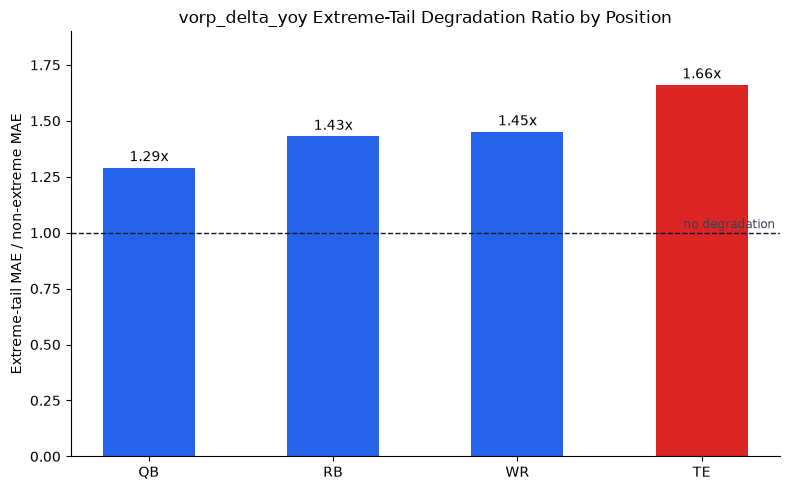

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

ratios = [DELTA_BUCKET_RATIO[p] for p in POSITIONS]
colors = ["#2563EB", "#2563EB", "#2563EB", "#DC2626"]
bars = ax.bar(POSITIONS, ratios, color=colors, width=0.5)

ax.axhline(1.0, color="#111827", linewidth=1, linestyle="--")
ax.annotate("no degradation", xy=(3.4, 1.02), fontsize=8.5, color="#374151", ha="right")

for bar, r in zip(bars, ratios):
    ax.annotate(f"{r:.2f}x", xy=(bar.get_x() + bar.get_width() / 2, r + 0.03), ha="center", fontsize=10)

ax.set_ylabel("Extreme-tail MAE / non-extreme MAE")
ax.set_title("vorp_delta_yoy Extreme-Tail Degradation Ratio by Position")
ax.set_ylim(0, 1.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Figure 2.** Ratio of model MAE on rows with `|vorp_delta_yoy| > 100` to MAE on rows at or below that threshold, by position. A ratio of 1.0 would indicate no degradation in the extreme tail. All four positions exceed 1.0; TE shows the largest degradation.

## Cross-Position Findings

### Finding 1: `scarcity_z` top-decile difficulty is universal, not position-specific

At every position, the held-out MAE within the top decile of `scarcity_z` (the model's dominant feature, representing standing above the field within the position-season) exceeds the model's overall held-out MAE. The bottom decile (replacement-level standing) shows the reverse pattern at a strikingly consistent magnitude.

| Position | Top-decile MAE ratio | Bottom-decile MAE ratio |
|---|---|---|
| QB | 1.16x | 0.55x |
| RB | 1.47x | 0.57x |
| WR | 1.50x | 0.59x |
| TE | 1.70x | 0.57x |

The bottom-decile ratio is confined to a narrow band (0.55x-0.59x) across four positions with unrelated feature sets and different sample sizes, indicating that replacement-level continuity is uniformly easy to predict. The top-decile ratio is larger and more variable (1.16x-1.70x) but exceeds 1.0 without exception. An unweighted average of the two extreme deciles together produces a figure close to, or below, the model's overall MAE at every position (QB's combined-decile average is 57.67 against an overall MAE of 67.28) — the asymmetry is visible only when the deciles are inspected separately.

The pattern holds across all four positions modeled, independent of whether the position's dominant mode of production is receiving, rushing, or passing. Elite single-season performances are harder to predict the continuation of than replacement-level performances are to predict the persistence of. This is a property of the model's dominant feature (`scarcity_z`) and its interaction with next-season outcomes generally, not a feature specific to any one position's role structure.

### Finding 2: `vorp_delta_yoy` extreme-tail degradation is confirmed at every position, magnitude not explained by position type

Rows with a large year-over-year VORP swing (`|vorp_delta_yoy| > 100`) show materially worse model accuracy than rows with a smaller swing, at every position:

| Position | Non-extreme MAE | Extreme-tail MAE | Ratio |
|---|---|---|---|
| QB | 51.88 | 67.16 | 1.29x |
| RB | 45.17 | 64.46 | 1.43x |
| WR | 37.09 | 53.90 | 1.45x |
| TE | 26.83 | 44.43 | 1.66x |

The ratio ranges from 1.29x to 1.66x and exceeds 1.0 at every position. It does not correspond to the same production-type grouping that Finding 1 initially appeared to (and did not) split along — QB and TE sit at the low and high ends of the range respectively, with RB and WR between them. No mechanism internal to the current feature sets accounts for the specific ordering or magnitude of the ratio across positions; the finding is that the direction and rough scale of the degradation replicate, not that its position-by-position size is explained.

Two candidate remediations were tested directly against QB's held-out folds and both were rejected on evidence: replacing `vorp_delta_yoy` with decomposed rate-of-change features was rejected by RFECV in every configuration tried, and winsorizing the feature at its 5th/95th percentile degraded both MAE and Spearman without moving the affected predictions toward more accurate values. `vorp_delta_yoy` remains in each position's locked feature set, with a `low_confidence_extreme_delta` flag (`|vorp_delta_yoy| > 100`) attached to every player-level prediction in each position notebook. Within the flagged region, Spearman rank correlation between predicted and actual outcomes remains close to each model's overall Spearman — the direction and relative ordering of a flagged prediction remain usable; the exact predicted value does not.

A related flag, `no_delta_history`, is set for any row with no computable prior-season VORP (a player with no prior qualifying season). This is distinct from `low_confidence_extreme_delta` and is not merged into it: an in-sample comparison against each position's shipped model shows no-delta-history rows fitting as well as or better than the general population and better than the extreme-delta bucket at every position (QB: 56.27 vs. 55.39 overall; RB: 38.36 vs. 43.21; WR: 31.00 vs. 34.15; TE: 20.73 vs. 25.08). This evidence is weaker than the held-out result in the table above, since it is measured in-sample rather than out-of-fold, but is consistent in direction across all four positions.

## Limitations

**Sample size.** Each position's walk-forward validation produces 8 folds. Per-fold test-season sizes are small in absolute terms — QB folds range from 51 to 67 rows, TE folds from 88 to 106 — and the extreme-delta bucket used in Finding 2 is smaller still: 18 rows for TE, 76 for WR, 81-103 for QB and RB. The direction of the extreme-tail degradation effect is consistent across positions; the exact ratio for any single position, particularly TE's, should be read as a point estimate with a wide implicit interval rather than a precise figure.

**The extreme-delta pattern is a documented weak spot, not a resolved one.** `vorp_delta_yoy` remains in every position's feature set because RFECV independently selects it and no tested alternative or transformation improves on it; the `low_confidence_extreme_delta` flag communicates reduced confidence in the exact predicted value for a flagged row but does not correct the underlying error.

**The `no_delta_history` evidence is in-sample.** The claim that rows with no prior-season VORP are not meaningfully harder to predict than the general population rests on in-sample error, evaluated on the same rows each model was fit on. A favorable in-sample result is weaker evidence of true generalization than an equivalent held-out result would be; the extreme-tail degradation in Finding 2, by contrast, is measured out-of-fold and carries correspondingly stronger evidentiary weight.

**TE's monotonic-constraint decision rests on a tiebreak, not a two-metric win.** Every other position's constraint decision (QB, RB, WR) shows one configuration winning on both MAE and Spearman simultaneously. TE's constrained configuration wins MAE while its unconstrained configuration wins Spearman by a margin below what fold-to-fold variation alone would be expected to produce; the shipped decision favors the metric that the tuning procedure directly optimizes, not a configuration that dominates on every measure.

**Feature sets are position-specific and not directly comparable in size or composition.** QB, RB, WR, and TE use 6, 4, 8, and 9 features respectively, each independently selected by RFECV under walk-forward cross-validation in Phase 3. Cross-position comparisons in this notebook (MAE, Spearman, the two diagnostic ratios) are valid as parallel, independently-derived results; they are not evidence that any one position's feature set or model architecture is more or less sound than another's.